# Personal Finance Pipeline — Walkthrough

This notebook demonstrates the end-to-end pipeline behind the personal finance
dashboard: turning a raw monthly bank export into categorized rows in the
centralized `data/transactions.csv` store, then computing the same monthly
aggregates the dashboard charts show.

Pipeline stages, all implemented in `finance_tracker/`:

1. **`loader.py`** — read a raw monthly bank export (xlsx/csv), normalize its columns
2. **`categorize.py`** — keyword rules assign Category / Sub-category / Method
3. **`pipeline.py`** — turn raw rows into the unified schema, hash-based dedup, merge into the store
4. **`overview.py`** — compute Monthly_Overview-style aggregates and category breakdowns
5. **`crypto.py`** — AES-256-GCM encryption for the store at rest (see `scripts/encrypt_store.py`)
6. **`overrides.py`** — user-taught merchant rules from the dashboard's "Needs Review" panel

The HTML dashboard (`dashboard/index.html`) re-implements the same categorize +
merge + dedup + encrypt logic in JavaScript so it can ingest a new monthly file
directly in the browser — this notebook is the reference implementation to
check it against.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "finance_tracker").exists() is False else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Raw personal bank exports are kept OUTSIDE this repo (one level up) since
# they contain real transaction data — see the .gitignore and README's
# Privacy section for why data/*.csv isn't tracked either.
RAW_DATA_DIR = PROJECT_ROOT.parent

import pandas as pd
from finance_tracker import loader, categorize, pipeline, overview, schema

pd.set_option("display.max_columns", None)
PROJECT_ROOT


PosixPath('/Users/enlt-dlopes/Documents/Dev_Notebooks/Projeto_1/personal_finances')

## 1. What a raw monthly export looks like

`descarga NOV-MAR.xlsx` is a raw bank statement download — one row per transaction,
with Portuguese column headers and no categorization at all.


In [2]:
raw = loader.read_raw_bank_file(RAW_DATA_DIR / "descarga NOV-MAR.xlsx")
print(f"{len(raw)} raw rows, date range {raw['Date'].min().date()} .. {raw['Date'].max().date()}")
raw.head()


207 raw rows, date range 2025-11-03 .. 2026-03-30


,Date,Description,Amount
0,2026-03-30,Transferência recebida,50.00
1,2026-03-30,Levantamento em numerário,-50.00
2,2026-03-30,Ordenado de Enlitia S A,1432.00
3,2026-03-27,S Martino Douro Pizz,-40.32
4,2026-03-27,Trf. MB WAY para Dr Duarte N Lopes,-22.00


## 2. Categorization rules

`categorize.categorize_transaction(description, amount)` applies keyword rules —
income rules when the amount is positive, expense rules when negative — and falls
back to a generic "Outro(s)" bucket so nothing is silently dropped. Matching is
whole-word, so short keywords like `ppr` don't false-positive on unrelated words.

A few examples, including three that used to be miscategorized:
- a pension-fund transfer, "Golden Sgf Soc Gestora Fundo Pensoes Sa" (was invisible
  to the Poupança/Investimento bucket entirely)
- an outgoing MB Way transfer (was forced into a blanket "Lazer" guess)

**MBWay is a payment rail, not a spending category** — a raw MB Way line is just
"Trf. MB WAY para \<name\>", with zero purpose signal (unlike a card purchase at a
named merchant), so it can't honestly be guessed as leisure spending. It routes to
**Transferências Pessoais** instead. The two directions are handled differently
on purpose: an *expense* gets the counterparty's name pulled out as the
sub-category (useful — shows how much flowed to a specific person over time),
while *income* just gets a fixed "Recebido" sub-category (who vaguely sent you
money isn't a useful "where did it go" signal the way who you paid is). `Method`
still records the rail (MBWay vs. Transferência) separately from the category
either way. This intentionally does **not** touch the historical seed data,
where the user manually looked up what each MBWay payment was actually for.


In [3]:
examples = [
    ("Ordenado de Enlitia S A", 1432.0),
    ("Repsol E1360", -66.33),
    ("Sould Park Bowling A", -28.0),
    ("Trf. MB WAY para Dr Duarte N Lopes", -22.0),
    ("Trf. MB WAY de Francisco Ribeiro Rocha Cs", 15.5),   # income -> fixed "Recebido", no name
    ("Transferência para Golden Sgf Soc Gestora Fundo Pensoes Sa", -2000.0),
    ("Trf.Imed.   P/ Degiro-E0312246", -200.0),
    ("Pf Petfiestas", -122.5),  # a pet store — must NOT match "ppr"/"etf"-style keywords
    ("Something Unrecognized Ltd", -15.0),
]
for desc, amount in examples:
    print(f"{desc!r:62s} {amount:>9.2f}  ->  {categorize.categorize_transaction(desc, amount)}")


'Ordenado de Enlitia S A'                                        1432.00  ->  ('Salário', 'Salário', 'Transferência')
'Repsol E1360'                                                    -66.33  ->  ('Necessário', 'Combustível', 'Cartão')
'Sould Park Bowling A'                                            -28.00  ->  ('Lazer', 'Desporto e Diversão', 'Cartão')
'Trf. MB WAY para Dr Duarte N Lopes'                              -22.00  ->  ('Transferências Pessoais', 'Dr Duarte N Lopes', 'MBWay')
'Trf. MB WAY de Francisco Ribeiro Rocha Cs'                        15.50  ->  ('Transferências Pessoais', 'Recebido', 'MBWay')
'Transferência para Golden Sgf Soc Gestora Fundo Pensoes Sa'    -2000.00  ->  ('Poupança/Investimento', 'PPR/Fundo de Pensões', 'Transferência')
'Trf.Imed.   P/ Degiro-E0312246'                                 -200.00  ->  ('Poupança/Investimento', 'Ações/ETF', 'Transferência')
'Pf Petfiestas'                                                  -122.50  ->  ('Outros', 'Outros', 'C

## 3. Ingest a monthly file into the unified schema

`pipeline.ingest_monthly_file()` combines steps 1 and 2 and shapes the result into
the same columns used by `data/transactions.csv` (see `finance_tracker/schema.py`).
Every row also gets a stable `transaction_id` — a SHA-1 hash of
`date | description | amount` — used later for deduplication.


In [4]:
categorized = pipeline.ingest_monthly_file(RAW_DATA_DIR / "descarga NOV-MAR.xlsx")
categorized.head()


,transaction_id,Date,Type,Category,Sub-category,Method,Amount (€),Notes,Month,Year,Source File
0,cb644cfe8082e0ab,2026-03-30,Income,Transferências Pessoais,Recebido,Transferência,50.00,Transferência recebida,3,2026,descarga NOV-MAR.xlsx
1,03eb84642550d455,2026-03-30,Expense,Geral,Levantamento,Levantamento,50.00,Levantamento em numerário,3,2026,descarga NOV-MAR.xlsx
2,b7cd88f352ecb081,2026-03-30,Income,Salário,Salário,Transferência,1432.00,Ordenado de Enlitia S A,3,2026,descarga NOV-MAR.xlsx
3,e84b7f065361865d,2026-03-27,Expense,Refeição,Restaurante,Cartão,40.32,S Martino Douro Pizz,3,2026,descarga NOV-MAR.xlsx
4,30be1f63684fff3b,2026-03-27,Expense,Transferências Pessoais,Dr Duarte N Lopes,MBWay,22.00,Trf. MB WAY para Dr Duarte N Lopes,3,2026,descarga NOV-MAR.xlsx


In [5]:
categorized["Category"].value_counts()


Category
Transferências Pessoais    83
Outros                     76
Comissões conta            12
Necessário                  9
Geral                       7
Lazer                       6
Salário                     5
Refeição                    4
Poupança/Investimento       2
Outro                       2
Saúde                       1
Name: count, dtype: int64

## 4. Merge into the centralized store, without duplicating

`data/transactions.csv` already holds this project's history (seeded once from
an Excel tracker via `scripts/seed_from_template.py`, plus this same monthly
file ingested earlier via `scripts/ingest_monthly.py`). Re-ingesting it here
should add **zero** new rows — that's the dedup contract the dashboard's
browser-side upload relies on too.


In [6]:
store = pipeline.load_store(PROJECT_ROOT / "data" / "transactions.csv")
merged, n_added, n_duplicate = pipeline.merge_into_store(store, categorized)
print(f"Store had {len(store)} rows. Adding this file: {n_added} new, {n_duplicate} already present.")
print(f"Store remains at {len(merged)} rows.")


Store had 354 rows. Adding this file: 0 new, 207 already present.
Store remains at 354 rows.


If this were genuinely a new month, `pipeline.save_store(merged, path)` would
write the merged result back to `data/transactions.csv` — that's exactly what
`scripts/ingest_monthly.py` does as a one-line CLI. We skip saving here since
nothing changed.


## 5. Monthly overview & category breakdown

`overview.compute_monthly_overview()` reproduces the template's `Monthly_Overview`
sheet: Income, Expenses (excluding savings/investment transfers), Net, and a
Savings/Investments column, grouped by Year + Month. Note December 2025's
Savings/Investments — that's the €2,000 pension-fund transfer now correctly
pulled out of "Expenses" and counted as savings instead.


In [7]:
monthly = overview.compute_monthly_overview(store)
monthly


,Year,Month,Income (€),Expenses (€),Net (€),Savings/Investments (€),Total Balance (€)
0,2025,9,2264.09,1282.33,981.76,0.0,981.76
1,2025,10,1879.40,1024.43,854.97,0.0,854.97
2,2025,11,5881.50,1335.28,4546.22,0.0,4546.22
3,2025,12,1606.59,1720.80,-114.21,2000.0,-2114.21
4,2026,1,1556.02,1311.64,244.38,0.0,244.38
5,2026,2,1584.10,932.69,651.41,200.0,451.41
6,2026,3,1654.50,1634.80,19.70,0.0,19.70


In [8]:
expense_breakdown = overview.compute_category_breakdown(store, schema.TYPE_EXPENSE)
income_breakdown = overview.compute_category_breakdown(store, schema.TYPE_INCOME)
expense_breakdown


,Category,Amount (€)
0,Outros,3276.86
1,Lazer,2223.78
2,Poupança/Investimento,2200.00
3,Transferências Pessoais,1624.19
4,Geral,725.24
5,Necessário,564.70
6,Refeição,427.36
7,Saúde,261.00
8,Natal,89.72
9,Comissões conta,29.12


## 6. The same three charts the dashboard shows

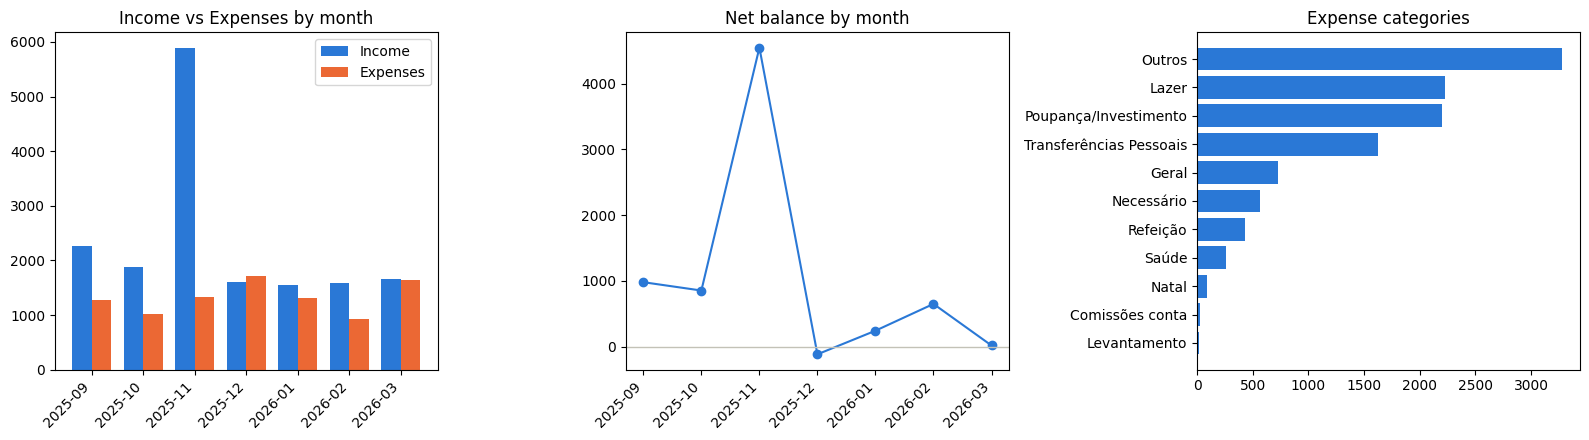

In [9]:
import matplotlib.pyplot as plt

SERIES_1, SERIES_2 = "#2a78d6", "#eb6834"  # same palette as dashboard/index.html

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

x = monthly["Year"].astype(str) + "-" + monthly["Month"].astype(str).str.zfill(2)
width = 0.38
axes[0].bar([i - width/2 for i in range(len(x))], monthly["Income (€)"], width, label="Income", color=SERIES_1)
axes[0].bar([i + width/2 for i in range(len(x))], monthly["Expenses (€)"], width, label="Expenses", color=SERIES_2)
axes[0].set_xticks(range(len(x)), x, rotation=45, ha="right")
axes[0].set_title("Income vs Expenses by month")
axes[0].legend()

axes[1].plot(x, monthly["Net (€)"], marker="o", color=SERIES_1)
axes[1].axhline(0, color="#c3c2b7", linewidth=1)
axes[1].set_xticks(range(len(x)), x, rotation=45, ha="right")
axes[1].set_title("Net balance by month")

top = expense_breakdown.sort_values("Amount (€)")
axes[2].barh(top["Category"], top["Amount (€)"], color=SERIES_1)
axes[2].set_title("Expense categories")

fig.tight_layout()
plt.show()


## 7. Teaching the categorizer: overrides

Two rows above stayed in the generic "Outros" bucket: "Pf Petfiestas" (a pet store) and
"Something Unrecognized Ltd". Rather than editing `categorize.py`'s source for every new
merchant, the dashboard's **"Needs Review"** panel lets you fix a transaction like this by hand
and, for `Outros` rows specifically, save the correction as a reusable rule — `overrides.py`
stores these in `data/category_overrides.json`, checked *before* the built-in rules by both the
dashboard and `scripts/ingest_monthly.py`.

This is intentionally **not** offered for `Transferências Pessoais` rows (MBWay / named
transfers): a merchant's category is a stable fact, but the same person might send you rent one
month and a birthday gift the next — learning "this name → this category" would silently
mis-categorize unrelated future transactions from them.


In [10]:
from finance_tracker import overrides as overrides_mod

my_overrides = overrides_mod.add_override(
    [], keywords=["petfiestas"], txn_type="expense",
    category="Necessário", sub_category="Animal de Estimação", method="Cartão",
)
print(categorize.categorize_transaction("Pf Petfiestas", -122.5, overrides=my_overrides))
print(categorize.categorize_transaction("Pf Petfiestas", -122.5))  # unchanged without the override


('Necessário', 'Animal de Estimação', 'Cartão')
('Outros', 'Outros', 'Cartão')


## Where this fits together

- `scripts/seed_from_template.py path/to/tracker.xlsx` — one-time import of an existing Excel tracker
- `scripts/ingest_monthly.py path/to/new_month.xlsx` — CLI equivalent of what this
  notebook did by hand in steps 3–4, run whenever a new monthly export arrives
- `scripts/encrypt_store.py` / `scripts/decrypt_store.py` — encrypt the store before
  committing it to git, decrypt it back to a working plaintext CSV locally
- `dashboard/index.html` — visualizes `data/transactions.csv` (plaintext or encrypted),
  can also ingest a new monthly file directly in the browser (same rules, same dedup
  hash), then offers "Download updated transactions.csv" or its encrypted equivalent.
  Its "Needs Review" panel is the interactive counterpart of `overrides.py` above —
  fix an "Outros" or "Transferências Pessoais" row by hand, optionally teaching a
  reusable merchant rule at the same time.
